In [2]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

import keras

In [3]:
casas = pandas.read_csv("https://github.com/dragonnomada/ml-cic-febrero-2026/blob/main/conjuntos/casas.csv?raw=true")

casas.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
casas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

<Axes: ylabel='Density'>

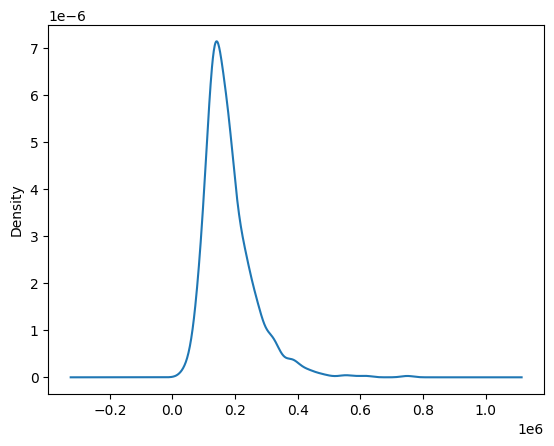

In [5]:
casas["SalePrice"].plot.density()

<Axes: ylabel='Density'>

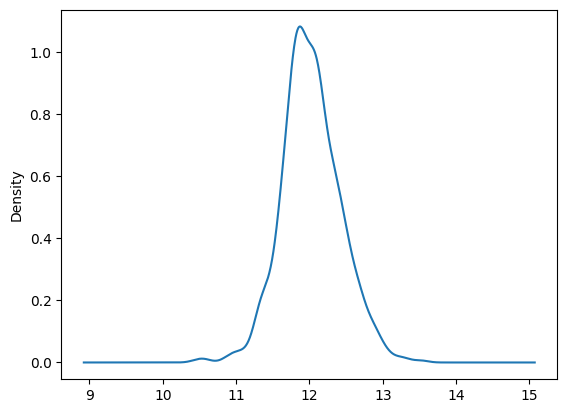

In [6]:
casas["SalePrice"].map(numpy.log1p).plot.density()

<Axes: >

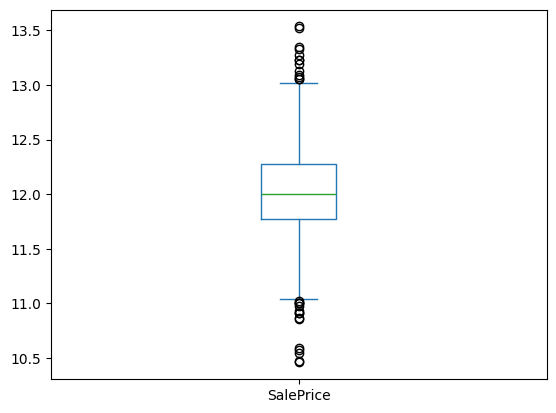

In [7]:
y = casas["SalePrice"].map(numpy.log1p)

y.plot.box()

In [8]:
numpy.expm1(12.3)

np.float64(219694.9886721379)

In [9]:
casas["MSZoning"].value_counts(normalize=True)

MSZoning
RL         0.788356
RM         0.149315
FV         0.044521
RH         0.010959
C (all)    0.006849
Name: proportion, dtype: float64

<Axes: >

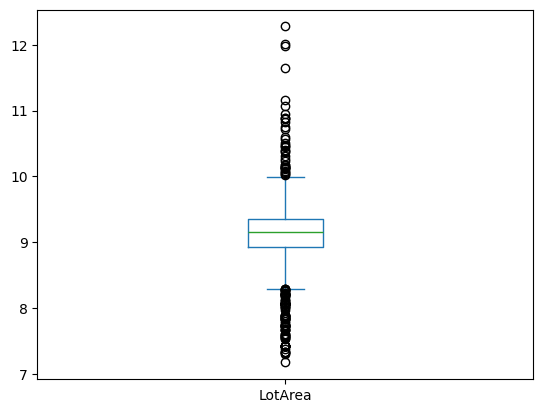

In [10]:
casas["LotArea"].map(numpy.log1p).plot.box()

<Axes: ylabel='Density'>

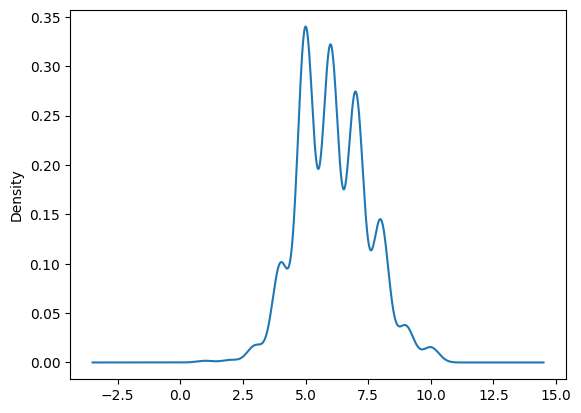

In [11]:
casas["OverallQual"].plot.density()

<Axes: >

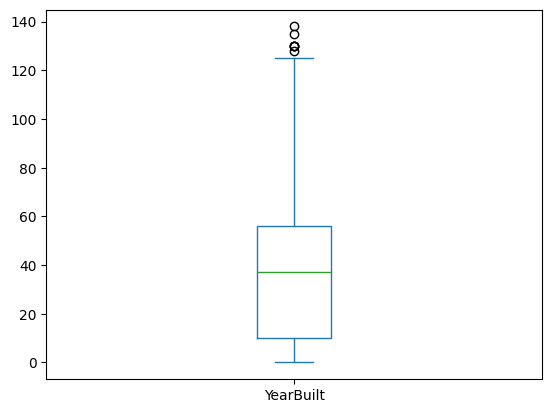

In [12]:
(casas["YearBuilt"].max() - casas["YearBuilt"]).plot.box()

In [13]:
casas["YearBuilt"].max()

np.int64(2010)

In [14]:
casas["YearRemodAdd"].max()

np.int64(2010)

<Axes: >

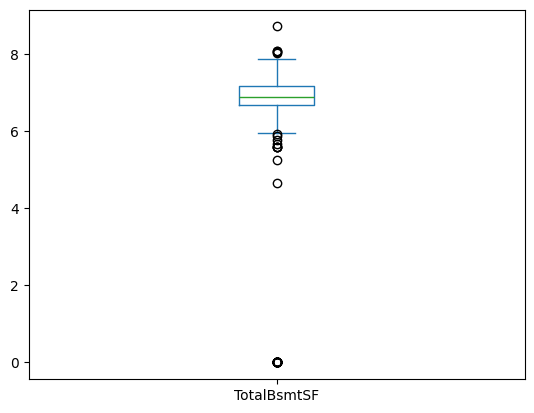

In [15]:
casas["TotalBsmtSF"].map(numpy.log1p).plot.box()

In [16]:
casas["CentralAir"].value_counts()

CentralAir
Y    1365
N      95
Name: count, dtype: int64

In [17]:
casas["BsmtFullBath"]

0       1
1       0
2       1
3       1
4       1
       ..
1455    0
1456    1
1457    0
1458    1
1459    1
Name: BsmtFullBath, Length: 1460, dtype: int64

In [18]:
casas["KitchenQual"].value_counts()

KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

In [19]:
casas["KitchenQual"].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

<Axes: ylabel='SalePrice'>

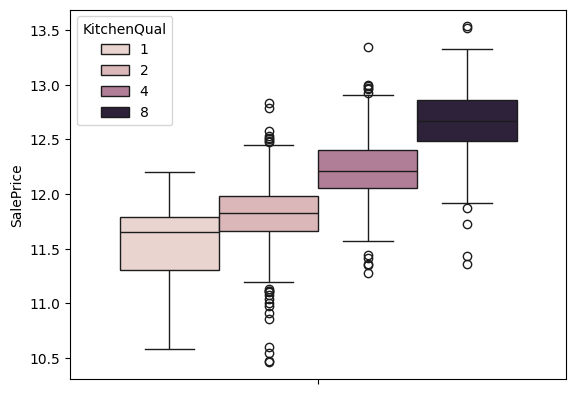

In [20]:
seaborn.boxplot(
    y=y,
    hue=casas["KitchenQual"].map({
        "Fa": 1,
        "TA": 2,
        "Gd": 4,
        "Ex": 8,
    })
)

<Axes: ylabel='SalePrice'>

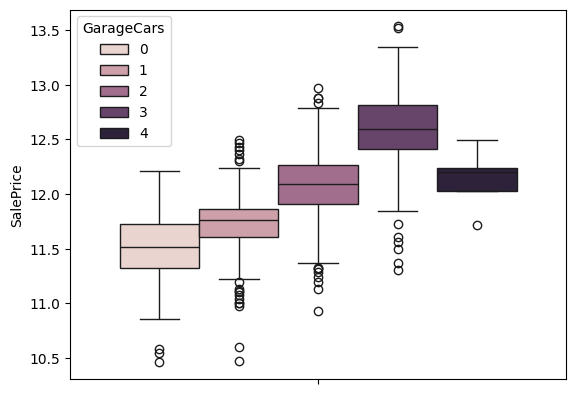

In [21]:
seaborn.boxplot(y=y, hue=casas["GarageCars"])

In [22]:
x1 = (casas["MSZoning"] == "RM").astype(int)
x2 = (casas["MSZoning"] == "FV").astype(int)
x3 = (casas["MSZoning"] == "RH").astype(int)
x4 = (casas["MSZoning"] == "C (all)").astype(int)

x1.name = "ZoningRM"
x2.name = "ZoningFV"
x3.name = "ZoningRH"
x4.name = "ZoningC"

x5 = casas["LotArea"].map(numpy.log1p)

x6 = casas["OverallQual"]

x7 = (casas["YearBuilt"].max() - casas["YearBuilt"])
x8 = (casas["YearRemodAdd"].max() - casas["YearRemodAdd"])

x9 = casas["TotalBsmtSF"].map(numpy.log1p)

x10 = casas["FullBath"] + 0.5 * casas["HalfBath"]
x11 = casas["BsmtFullBath"] + 0.5 * casas["BsmtHalfBath"]

x10.name = "TotalBaths"
x11.name = "TotalBsmtBaths"

x12 = casas["KitchenQual"].map({
    "Fa": 1,
    "TA": 2,
    "Gd": 4,
    "Ex": 8,
})

x13 = casas["GarageCars"]

X = pandas.DataFrame([
    x1, x2, x3, x4, x5, x6, x7,
    x8, x9, x10, x11, x12, x13,
]).T

X

,ZoningRM,ZoningFV,ZoningRH,ZoningC,LotArea,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,TotalBaths,TotalBsmtBaths,KitchenQual,GarageCars
0,0.0,0.0,0.0,0.0,9.042040,7.0,7.0,7.0,6.753438,2.5,1.0,4.0,2.0
1,0.0,0.0,0.0,0.0,9.169623,6.0,34.0,34.0,7.141245,2.0,0.5,2.0,2.0
2,0.0,0.0,0.0,0.0,9.328212,7.0,9.0,8.0,6.825460,2.5,1.0,4.0,2.0
3,0.0,0.0,0.0,0.0,9.164401,7.0,95.0,40.0,6.629363,1.0,1.0,4.0,3.0
4,0.0,0.0,0.0,0.0,9.565284,8.0,10.0,10.0,7.044033,2.5,1.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.0,0.0,0.0,0.0,8.976894,6.0,11.0,10.0,6.860664,2.5,0.0,2.0,2.0
1456,0.0,0.0,0.0,0.0,9.486152,6.0,32.0,22.0,7.341484,2.0,1.0,2.0,2.0
1457,0.0,0.0,0.0,0.0,9.109746,7.0,69.0,4.0,7.050123,2.0,0.0,4.0,1.0
1458,0.0,0.0,0.0,0.0,9.181735,5.0,60.0,14.0,6.983790,1.0,1.0,4.0,1.0


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=200, random_state=123)

<Axes: ylabel='SalePrice'>

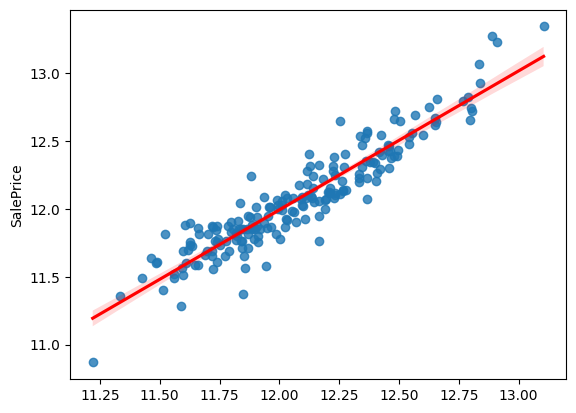

In [24]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

yp = modelo.predict(X_test)

seaborn.regplot(x=yp, y=y_test, line_kws={"color": "red"})

<Axes: xlabel='SalePrice', ylabel='Density'>

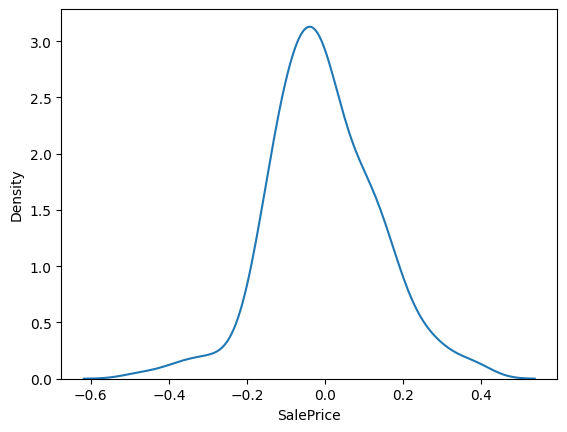

In [25]:
e = y_test - yp

seaborn.kdeplot(x=e)

In [26]:
numpy.expm1(0.2)

np.float64(0.22140275816016985)

In [30]:
SSE = e.dot(e)
MSE = SSE.mean()
RMSE = MSE ** 0.5
SAE = e.abs().sum()
MAE = e.abs().mean()

pandas.DataFrame({
    "SSE": [SSE],
    "MSE": [MSE],
    "RMSE": [RMSE],
    "SAE": [SAE],
    "MAE": [MAE],
}).T

,0
SSE,3.835974
MSE,3.835974
RMSE,1.958564
SAE,21.249880
MAE,0.106249


In [32]:
numpy.expm1(0.106249)

np.float64(0.11209875462367598)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 100)            │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,701 (84.77 KB)

 Trainable params: 21,701 (84.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 151.0849 - mae: 11.4963  
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34.7442 - mae: 4.7972 
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.4889 - mae: 1.4961 
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0892 - mae: 1.0725 
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1072 - mae: 0.8472 
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6508 - mae: 0.5954 
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5428 - mae: 0.5412 
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4650 - mae: 0.4926 
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4278 - mae: 0.4875 
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4053 - mae: 0.4550 
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3112 - mae: 0.4048 
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3051 - mae: 0.3949 
Epoch 13

<Axes: ylabel='SalePrice'>

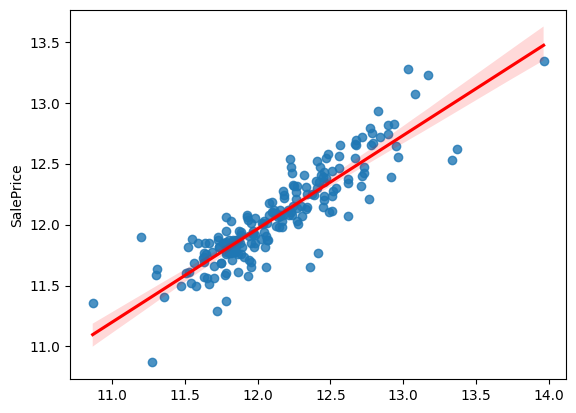

In [48]:
modelo = keras.Sequential([
    keras.Input(shape=(13,)),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(1, activation="linear"),
])

modelo.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

modelo.summary()

modelo.fit(X_train, y_train, epochs=1000, batch_size=100)

yp = modelo.predict(X_test)[:, 0]

seaborn.regplot(x=yp, y=y_test, line_kws={"color": "red"})

<Axes: xlabel='SalePrice', ylabel='Density'>

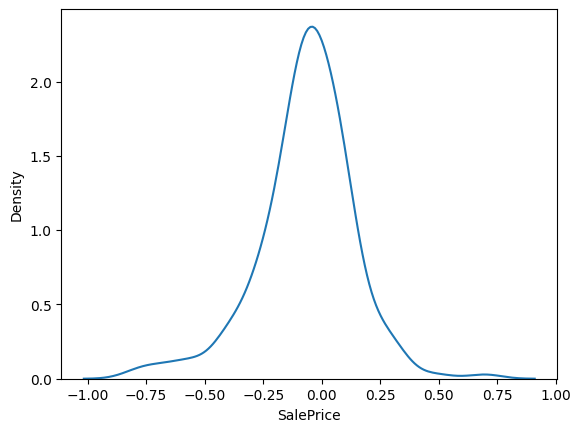

In [49]:
e = y_test - yp

seaborn.kdeplot(x=e)

In [50]:
SSE = e.dot(e)
MSE = SSE.mean()
RMSE = MSE ** 0.5
SAE = e.abs().sum()
MAE = e.abs().mean()

pandas.DataFrame({
    "SSE": [SSE],
    "MSE": [MSE],
    "RMSE": [RMSE],
    "SAE": [SAE],
    "MAE": [MAE],
}).T

,0
SSE,9.269581
MSE,9.269581
RMSE,3.044599
SAE,30.709663
MAE,0.153548
